# XGBoost Modeling

This notebook trains and evaluates an XGBoost model
for predicting tract-level grocery store density.

Input:
- Processed tract-level dataset (.parquet)

Output:
- Trained XGBoost model
- Performance metrics
- Feature importance analysis

## Config

In [1]:
# %%
CITY = "new_york_city"

DATA_PATH = f"../data/{CITY}_tract_dataset.parquet"

TARGET_VARIABLE = "grocery_density"

MODEL_FEATURES = [
    "population_density",
    "median_income",
    "pct_under_18",
    "pct_over_65",
    "pct_bachelors_degree",
    "employment_rate",
    "poverty_rate",
    "road_density",
    "intersection_density",
    "transit_stop_density"
]

## Imports

In [2]:
# %%
import numpy as np
import pandas as pd
import geopandas as gpd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_squared_error,
    r2_score
)

from sklearn.preprocessing import StandardScaler

import xgboost as xgb

## Load dataframe

In [5]:
gdf = gpd.read_parquet(DATA_PATH)

print("Dataset shape:", gdf.shape)

gdf.head()

Dataset shape: (2081, 14)


,tract_id,geometry,total_population,population_density,median_income,pct_under_18,pct_over_65,pct_bachelors_degree,employment_rate,poverty_rate,road_density,intersection_density,transit_stop_density,grocery_density
0,36081003400,"POLYGON ((-73.8663 40.68319, -73.86549 40.6834...",2559,6869.633349,79728.0,0.178585,0.117233,0.262774,0.869735,0.160126,35.570357,64.427980,21.475993,0.000000
1,36081003900,"POLYGON ((-73.9433 40.76066, -73.94247 40.7619...",1436,5599.661929,53468.0,0.157382,0.072423,0.327256,0.989781,0.227019,43.399214,31.195888,23.396916,0.000000
2,36081003600,"POLYGON ((-73.8641 40.68237, -73.8637 40.68248...",4004,12778.128973,86582.0,0.255245,0.155345,0.235552,0.909272,0.082371,47.504958,41.487432,0.000000,3.191341
3,36081003800,"POLYGON ((-73.8528 40.68425, -73.85196 40.6844...",2514,8195.434026,85859.0,0.280827,0.095465,0.314629,0.949377,0.116640,52.409901,58.678525,26.079345,0.000000
4,36081004001,"POLYGON ((-73.85113 40.68281, -73.85028 40.683...",2241,7386.461753,82176.0,0.211959,0.098170,0.163265,0.983092,0.149933,46.137130,26.368449,16.480281,0.000000


## Prepare data

In [6]:
def prepare_model_data(gdf):

    print("\nPreparing modeling dataset...")

    df = gdf.copy()

    # remove missing values
    df = df.replace([np.inf, -np.inf], np.nan)

    df = df.dropna(
        subset=MODEL_FEATURES + [TARGET_VARIABLE]
    ).copy()

    # predictors
    X = df[MODEL_FEATURES].copy()

    # target
    y = df[TARGET_VARIABLE].copy()

    print("Final shape:", df.shape)

    return X, y, df

In [7]:
X, y, model_df = prepare_model_data(gdf)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))


Preparing modeling dataset...
Final shape: (2081, 14)
Train size: 1664
Test size: 417


## Train XGBoost model

In [9]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [10]:
xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train_scaled,
    y_train
)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [11]:
y_pred = xgb_model.predict(
    X_test_scaled
)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

r2 = r2_score(y_test, y_pred)

print("\nXGBoost Results")
print("RMSE:", round(rmse, 4))
print("R²:", round(r2, 4))


XGBoost Results
RMSE: 6.0906
R²: 0.4083


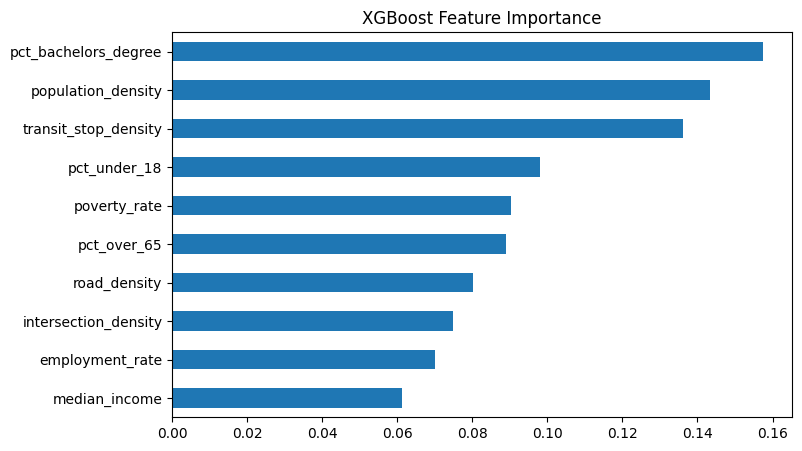

In [12]:
importances = pd.Series(
    xgb_model.feature_importances_,
    index=MODEL_FEATURES
).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))

importances.plot.barh(ax=ax)

ax.set_title("XGBoost Feature Importance")

plt.show()

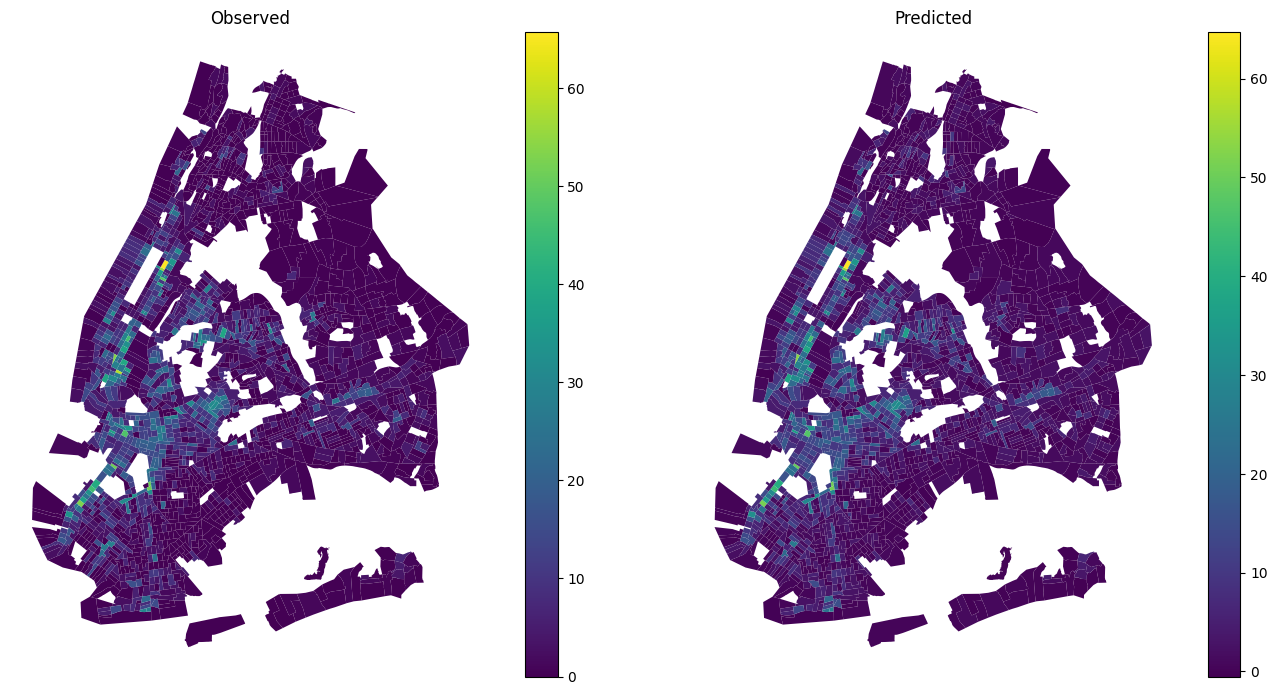

In [13]:
model_df["prediction"] = xgb_model.predict(
    scaler.transform(model_df[MODEL_FEATURES])
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 7)
)

model_df.plot(
    column=TARGET_VARIABLE,
    cmap="viridis",
    legend=True,
    ax=axes[0]
)

axes[0].set_title("Observed")

model_df.plot(
    column="prediction",
    cmap="viridis",
    legend=True,
    ax=axes[1]
)

axes[1].set_title("Predicted")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()